## Übung3 ##

2. Implementieren Sie eine Funktion, die es erlaubt ein Bild (im sinnvollen Rahmen) mit frei wählbaren Filtermasken zu falten.

• Prototyp: [ out image ] = filter(in image, filter, off)
– out image: Ergebnisbild (int) nach Faltung von in image mit filter
– filter: Filtermatrix (float)
– off: Offset(int). Der Offset, auch bekannt als stride, gibt an, um wie viele Pixel
die Filtermatrix verschoben wird. Bei einem offset > 1, wird die Bildgr¨osse
deutlich verkleinert.
– 8-Bit Graustufenbilder als Eingangs- und Ausgangsdaten.
– Filtermatrix der Größe (NxN) mit N = (2K + 1), K = 1, 2, ...
– Beispielaufruf: filter(image, [1 1 1; 1 3 1; 1 1 1]/11, 1)

In [34]:
from skimage import io
import matplotlib.pyplot as plt
import numpy as np

In [35]:
#bild einlesen
pfad = "C:/Users/Ann-Kathrin/Desktop/htwg/semester05/2DCV/uebung3/"
img = io.imread(pfad + "lena.jpg")

In [36]:
#bild bunt zu grau
if len(img.shape) == 3:
    img = (
        0.299 * img[:, :, 0] +
        0.587 * img[:, :, 1] +
        0.114 * img[:, :, 2]
    ).astype(np.uint8)

In [51]:
#Aufgabe 1.2 Filterfunktion mit frei wählbarer Filtermaske

def simple_filter(in_image, filter_matrix, offset=1): #offset gibt an um wie viele Pixel die Filtermatrix verschoben

    img_h, img_w = in_image.shape #bildgrößen holen
    filter_size = filter_matrix.shape[0] #zb bei 3x3 filtersize = 3
    k = filter_size // 2 #mod k = 1 fuer mitte (index 0,1,2 -> mitte = 1)

    out_h = (img_h - filter_size) // offset + 1  #(bilderhöhe - filterhöhe) mod weil nicht jeden pixel, springen
    out_w = (img_w - filter_size) // offset + 1

    out_image = np.zeros((out_h, out_w), dtype=np.uint8)
    out_y = 0

    for y in range(k,img_h - k, offset):
        out_x = 0

        for x in range(k, img_w - k, offset):

            value = 0.0

            # Faltung
            for fy in range(-k, k + 1):
                for fx in range(-k, k + 1):

                    pixel = in_image[y + fy, x + fx] #keine Kontrolle über rand!!
                    weight = filter_matrix[fy + k, fx + k]
                    value += pixel * weight #gewichtete Summe (neuer Pixel = Sum(Nachbarpixel * Gewicht))

            out_image[out_y, out_x] = np.clip(value, 0, 255)

            out_x += 1
        out_y += 1

    return out_image

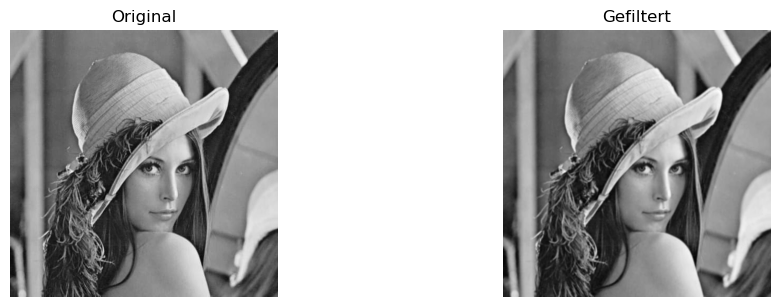

In [50]:
# # test
filter_matrix = np.array([ #leichte glättung
    [1, 1, 1],
    [1, 3, 1],
    [1, 1, 1]
 ], dtype=float) /11 #durch summe teilen

out = simple_filter(img, filter_matrix, 1)


plt.figure(figsize=(10, 6))

plt.subplot(2, 2, 1)
plt.title("Original")
plt.imshow(img, cmap="gray")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.title("Gefiltert")
plt.imshow(out, cmap="gray")
plt.axis("off")


plt.tight_layout()
plt.show()

3. Erweitern Sie die Funktion filter() aus Aufgabe 2 um folgende Randbedingungen: <br>
• min: Setzt Bildpunkte auf den minimalen Wert (0). Dies wird auch als zero padding
bezeichnet. <br>
• max: Setzt Bildpunkte auf den maximalen Wert (255) <br>
• continue: Setzt das Bild ausserhalb mit dem gleichen Pixelwert, wie das entsprechende am n¨achsten liegende Randpixel, fort. <br>
• Untersuchen Sie die Randbehandlungen auf ihr Verhalten bei Benutzung verschiedener Filter. <br>
• Prototyp: [ out image ] = filter(in image, filter, off, edge);– edge: Parameter zur Auswahl der Randbehandlung (’min’)- String

In [39]:
#aufgabe 1.3
def get_pixel(in_image, x, y, edge):

    img_h, img_w = in_image.shape

    if 0 <= x < img_h and 0 <= y < img_w:
        return in_image[x, y]

    #wenn pixel ausserhalb 
    if edge == "min":
        return 0 #schwarz

    if edge == "max":
        return 255 #weiß

    if edge == "continue": #rand wird verlängert (kopiert)
        x = min(max(x, 0), img_h - 1)
        y = min(max(y, 0), img_w - 1)
        return in_image[x, y]


In [40]:
#simple filter mit erweiterung
def advanced_filter(in_image, filter_matrix, offset=1, edge='continue'):

    img_h, img_w = in_image.shape
    filter_size = filter_matrix.shape[0]
    k = filter_size // 2

    out_h = img_h // offset
    out_w = img_w // offset

    out_image = np.zeros((out_h, out_w), dtype=np.uint8)

    out_y = 0

    for y in range(0, img_h, offset):
        out_x = 0

        for x in range(0, img_w, offset):

            value = 0.0

            for fy in range(-k, k + 1):
                for fx in range(-k, k + 1):

                    pixel = get_pixel(in_image, y + fy, x + fx, edge) #mit randbehandlung!!
                    weight = filter_matrix[fy + k, fx + k]

                    value += pixel * weight

            out_image[out_y, out_x] = int(np.clip(value,0,255))

            out_x += 1
        out_y += 1

    return out_image

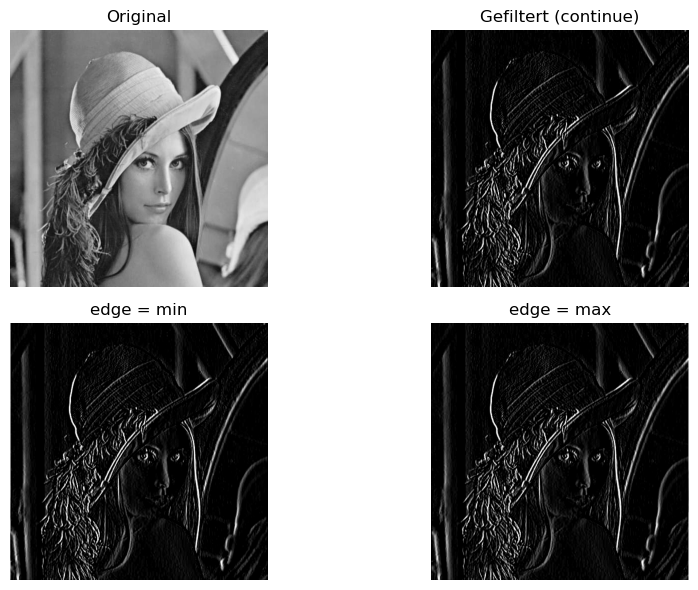

In [53]:


filter_matrix = np.array([ #Kantenfilter (horizontale Kanten |)
   [-1,0,1],
   [-2,0,2],
   [-1,0,1]
   ])

#filter_matrix = np.array([ #Glättungsfilter
# [1,1,1],
# [1,1,1],
# [1,1,1]
#]) / 9

# test
out1 = advanced_filter(img, filter_matrix, 1, "continue")
out_min = advanced_filter(img, filter_matrix, 1, "min")
out_max = advanced_filter(img, filter_matrix, 1, "max")



plt.figure(figsize=(10, 6))

plt.subplot(2, 2, 1)
plt.title("Original")
plt.imshow(img, cmap="gray")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.title("Gefiltert (continue)")
plt.imshow(out1, cmap="gray")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.title("edge = min")
plt.imshow(out_min, cmap="gray")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.title("edge = max")
plt.imshow(out_max, cmap="gray")
plt.axis("off")

plt.tight_layout()
plt.show()

#aufgabe 1.4 Fragen: <br>
a) Nennen Sie die Arten und Eigenschaften von linearen Filtern. <br>
-Arten von linearen Filtern: <br>
Glättungsfilter (Tiefpassfilter,lässt tiefe durch) (z. B. Box-Filter, Gauß-Filter) (reduzieren Rauschen durch Mittelung benachbarter Pixel.) <br>
Differenzfilter (Hochpassfilter) (z. B. Laplace-Filter, Sobel-Filter, Schärfefilter) (verstärken lokale Intensitätsunterschiede und werden zur Kanten- oder Konturerkennung verwendet.) <br>

-Eigenschaften von linearen Filtern: <br>
lineare Filter arbeiten durch Faltung (gewichtete Summe der Nachbarschaft) <br>
sie erfüllen das Superpositionsprinzip <br>
Ergebnis ist eine lineare Kombination der Pixelwerte <br>
sie sind unabhängig von lokalen Bildinhalten <br>
gut mathematisch beschreibbar und effizient berechenbar 


b) Was ist der Unterschied zwischen linearen und nichtlinearen Filtern? <br>
linear: basiert auf Faltung (gewichtete Summe), glättet oder hebt Kanten hervor, <br>
empfindlich gegenüber Ausreißern <br>
nichtlinear: entfernt Salt-and-Pepper-Rauschen sehr gut, erhält Kanten besser

#aufgabe 2.2 Implementieren Sie den Medianfilter. <br>
• Prototyp: out image = medianFilter(in image, filtersize, offset) <br>
out image: Ergebnisbild nach Faltung von in image mit filter
in image: Eingangbild (int); 8-Bit Graustufenbilder <br>
filtersize: Filtergr¨osse (int); Gr¨osse (NxN) mit N = (2K + 1), K = 1, 2, ... <br>
offset: Offset (int) <br>
Beispielaufruf: medianFilter(image, 3, 1) <br>
Benutzung Sie f¨ur die Sortierung wenn m¨oglich Heap Sort <br>

In [42]:
# Bild laden
img2 = io.imread("pepper.jpg")

In [43]:
def heapify(arr, n, i): #prüft heap regeln
    largest = i #parent
    left = 2 * i + 1 #linkes Kind
    right = 2 * i + 2 #rechtes kind

    #Größtes Element finden
    if left < n and arr[left] > arr[largest]:
        largest = left

    if right < n and arr[right] > arr[largest]:
        largest = right

    if largest != i:
        arr[i], arr[largest] = arr[largest], arr[i]
        heapify(arr, n, largest)


def heapSort(arr): #heapsort
    n = len(arr)

    # baue max heap
    for i in range(n // 2 - 1, -1, -1):
        heapify(arr, n, i)

    for i in range(n - 1, 0, -1):
        arr[0], arr[i] = arr[i], arr[0] #größtes Element nach hinten
        heapify(arr, i, 0)

In [69]:
def medianFilter(in_image, filtersize, offset=1): #Er ersetzt jeden Pixel durch den Median seiner Nachbarschaft.

    h, w = in_image.shape
    k = filtersize // 2  #Mittelpunkt des Filters

    out_h = (h) // offset + 1
    out_w = (w) // offset + 1

    out_image = np.zeros((out_h, out_w), dtype=np.uint8)

    out_y = 0

    for y in range(0, h - k, offset):
        out_x = 0

        for x in range(0, w - k, offset):

            window = []

            # Nachbarschaft sammeln
            for fy in range(-k, k + 1):
                for fx in range(-k, k + 1):
                    window.append(int(in_image[y + fy, x + fx]))

            #Heap Sort anwenden
            heapSort(window) #window.sort()

            # Median nehmen
            median = window[len(window) // 2]

            out_image[out_y, out_x] = median

            out_x += 1
        out_y += 1

    return out_image

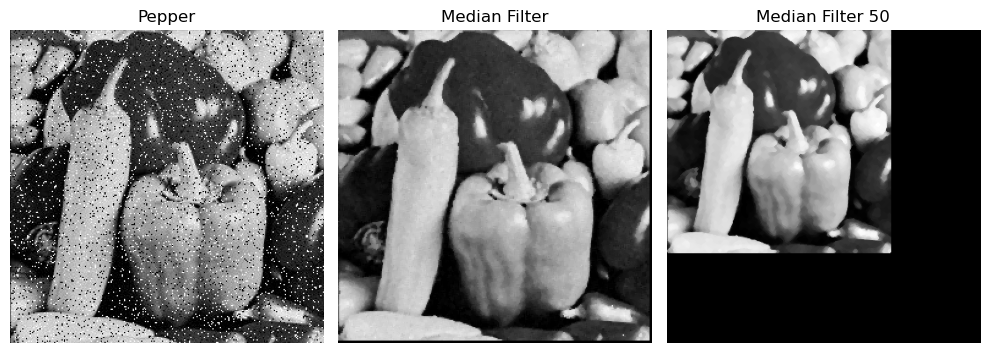

In [ ]:
# Medianfilter anwenden
out = medianFilter(img2, 4, 1) #bsp aufruf
n = 100
out2 = out.copy()
for i in range(n) :
    out2 = medianFilter(out2, 4, 1)
#out = medianFilter(img2, 7, 1) # bild noch glatter
#out = medianFilter(img2, 3, 2) #offset größer -> springt immer 2 Pixel
plt.figure(figsize=(10,5))

plt.subplot(1,3,1)
plt.title("Pepper")
plt.imshow(img2, cmap="gray")
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Median Filter")
plt.imshow(out, cmap="gray")
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Median Filter 50")
plt.imshow(out2, cmap="gray")
plt.axis("off")

plt.tight_layout()
plt.show()

#aufgabe 3 Fragen: <br>

a) Vergleichen Sie die Ergebnisse der verschiedenen Filter miteinander und begründen Sie diese. <br>

*Lineare Filter (Mittelwertfilter) glätten das Bild, indem sie den Durchschnitt der Nachbarschaft berechnen. Dadurch werden Rauschen und Details gleichzeitig reduziert. <br>

*Der Medianfilter hingegen ersetzt jeden Pixel durch den Median seiner Nachbarn und entfernt dadurch besonders effektiv Ausreißer wie Salt-and-Pepper-Rauschen, ohne Kanten stark zu verwischen.
<br>
<br>
b) Warum ist es beim Medianfilter sinnvoll für die Sortierung Heap Sort zu verwenden? <br>

Der Medianfilter benötigt eine Sortierung der Nachbarschaftswerte. Heap Sort ist dabei effizient mit garantierter Laufzeit von O(n log n) und benötigt wenig zusätzlichen Speicher, was bei vielen lokalen Sortierungen im Bild vorteilhaft ist. <br>


c) Untersuchen Sie, welche Effekte bei mehrmaligem Anwenden eines Filters auf das jeweilige Ergebnisbild auftreten. <br>

Bei mehrfacher Anwendung eines Filters werden Effekte verstärkt. Beim Medianfilter wird das Bild zunehmend geglättet, kleine Details verschwinden und das Bild kann „blockartig“ wirken.


d) Welche Effekte treten bei grossen und bei kleinen Filtermasken auf? <br>

Kleine Filtermasken entfernen nur wenig Rauschen, erhalten aber viele Details. Große Filtermasken entfernen starkes Rauschen besser, führen jedoch zu deutlichem Detailverlust und stärkeren Glättungseffekten.